In [15]:
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [16]:
# get data
data_path = "data"

log2tpm_path = "GSE62944_subsample_log2TPM.csv"

metadata_path = "GSE62944_metadata.csv"

log2tpm = pd.read_csv(os.path.join(data_path, log2tpm_path), index_col=0)
metadata = pd.read_csv(os.path.join(data_path, metadata_path), index_col=0)

display(log2tpm.head())
display(metadata.head())

,TCGA-E9-A1NI-01A-11R-A14D-07,TCGA-E2-A1LK-01A-21R-A14D-07,TCGA-BH-A0B2-01A-11R-A10J-07,TCGA-E2-A107-01A-11R-A10J-07,TCGA-LL-A5YN-01A-11R-A28M-07,TCGA-BH-A0DQ-01A-11R-A084-07,TCGA-D8-A73X-01A-11R-A32P-07,TCGA-AR-A0TP-01A-11R-A084-07,TCGA-E2-A1IF-01A-11R-A144-07,TCGA-EW-A6SD-01A-12R-A33J-07,...,TCGA-N5-A4RF-01A-11R-A28V-07,TCGA-N6-A4VF-01A-31R-A28V-07,TCGA-N5-A4RN-01A-12R-A28V-07,TCGA-QM-A5NM-01A-11R-A28V-07,TCGA-N5-A4RJ-01A-11R-A28V-07,TCGA-N5-A4RO-01A-11R-A28V-07,TCGA-N5-A4RV-01A-21R-A28V-07,TCGA-N6-A4VD-01A-11R-A28V-07,TCGA-N5-A4RT-01A-11R-A28V-07,TCGA-ND-A4WC-01A-21R-A28V-07
A1BG,3.397369,3.466089,3.789771,3.967578,4.733007,3.011343,4.324578,3.687565,2.399717,4.233443,...,4.434854,3.630666,3.575404,2.458971,5.791871,3.535440,6.075494,4.383862,4.488649,3.182423
A1CF,0.008857,0.039562,0.065051,0.000000,0.014260,0.008014,0.021112,0.020984,0.025614,0.108061,...,0.044659,0.007317,0.015572,0.035358,1.949092,0.078157,0.021624,0.006336,0.019464,0.091276
A2M,7.575125,6.643613,9.024479,7.573842,7.459105,9.279760,7.526283,12.770294,8.201515,8.065138,...,9.212672,10.137570,8.439769,5.508460,6.958057,7.928136,9.668470,8.952802,6.137774,7.317486
A2ML1,0.397610,7.625124,0.428689,0.465410,1.126008,0.083225,0.274456,0.220169,0.152375,1.333526,...,0.063074,0.546730,0.744056,2.409112,0.686557,0.088065,3.002216,0.977974,0.568217,0.012821
A4GALT,5.277425,5.244677,4.072650,4.208381,5.249234,5.123996,5.465881,3.083101,5.371876,3.027163,...,4.821015,5.287393,4.690114,4.438399,4.914086,3.492874,2.089483,5.706015,4.227761,5.491313


,cancer_type,bcr_patient_barcode,bcr_patient_uuid,patient_id,gender,race,ethnicity,age_at_diagnosis,age_at_initial_pathologic_diagnosis,birth_days_to,...,ajcc_pathologic_t,history_hormonal_contraceptives_use,pregnancies_count_miscarriage,jewish_religion_heritage_indicator,tobacco_smoking_age_started,family_history_cancer_type,tumor_response,ecog_score,lymph_nodes_examined_count,residual_tumor.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-E9-A1NI-01A-11R-A14D-07,BRCA,TCGA-E9-A1NI,c65b835a-2d38-4250-a173-0780d2c2cf58,A1NI,FEMALE,WHITE,NOT HISPANIC OR LATINO,51.0,NaN,-18985,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN
TCGA-E2-A1LK-01A-21R-A14D-07,BRCA,TCGA-E2-A1LK,1d27253f-b036-44e7-a04d-8da5bbf57419,A1LK,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,84.0,NaN,-30757,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN
TCGA-BH-A0B2-01A-11R-A10J-07,BRCA,TCGA-BH-A0B2,57a1604c-60b7-4b30-a75e-f70939532c5c,A0B2,FEMALE,WHITE,NOT HISPANIC OR LATINO,43.0,NaN,-15917,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN
TCGA-E2-A107-01A-11R-A10J-07,BRCA,TCGA-E2-A107,eff2360e-399a-4167-ab2b-798e27bef739,A107,FEMALE,WHITE,NOT HISPANIC OR LATINO,54.0,NaN,-20065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Not Available],NaN
TCGA-LL-A5YN-01A-11R-A28M-07,BRCA,TCGA-LL-A5YN,EF1B3332-CD7F-41BB-A2D3-2538E7BECC5C,A5YN,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,46.0,NaN,-16884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN


In [17]:
# split by specific cancer vs not
metadata["PRAD_pos"] = metadata["cancer_type"].apply(lambda x: "PRAD" in x)
display(metadata)

,cancer_type,bcr_patient_barcode,bcr_patient_uuid,patient_id,gender,race,ethnicity,age_at_diagnosis,age_at_initial_pathologic_diagnosis,birth_days_to,...,history_hormonal_contraceptives_use,pregnancies_count_miscarriage,jewish_religion_heritage_indicator,tobacco_smoking_age_started,family_history_cancer_type,tumor_response,ecog_score,lymph_nodes_examined_count,residual_tumor.1,PRAD_pos
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-E9-A1NI-01A-11R-A14D-07,BRCA,TCGA-E9-A1NI,c65b835a-2d38-4250-a173-0780d2c2cf58,A1NI,FEMALE,WHITE,NOT HISPANIC OR LATINO,51.0,NaN,-18985,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,False
TCGA-E2-A1LK-01A-21R-A14D-07,BRCA,TCGA-E2-A1LK,1d27253f-b036-44e7-a04d-8da5bbf57419,A1LK,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,84.0,NaN,-30757,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,False
TCGA-BH-A0B2-01A-11R-A10J-07,BRCA,TCGA-BH-A0B2,57a1604c-60b7-4b30-a75e-f70939532c5c,A0B2,FEMALE,WHITE,NOT HISPANIC OR LATINO,43.0,NaN,-15917,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,False
TCGA-E2-A107-01A-11R-A10J-07,BRCA,TCGA-E2-A107,eff2360e-399a-4167-ab2b-798e27bef739,A107,FEMALE,WHITE,NOT HISPANIC OR LATINO,54.0,NaN,-20065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[Not Available],NaN,False
TCGA-LL-A5YN-01A-11R-A28M-07,BRCA,TCGA-LL-A5YN,EF1B3332-CD7F-41BB-A2D3-2538E7BECC5C,A5YN,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,46.0,NaN,-16884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-N5-A4RO-01A-11R-A28V-07,UCS,TCGA-N5-A4RO,4F4906DC-7EBD-47F1-A8F5-B35D3950E740,A4RO,FEMALE,BLACK OR AFRICAN AMERICAN,[Not Evaluated],NaN,67,NaN,...,[Unknown],NaN,NaN,NaN,NaN,NaN,NaN,NaN,RX,False
TCGA-N5-A4RV-01A-21R-A28V-07,UCS,TCGA-N5-A4RV,3AF5B391-E72F-463D-A086-A86C6C30A51A,A4RV,FEMALE,WHITE,[Not Evaluated],NaN,62,NaN,...,[Unknown],NaN,NaN,NaN,NaN,NaN,NaN,NaN,R0,False
TCGA-N6-A4VD-01A-11R-A28V-07,UCS,TCGA-N6-A4VD,14213209-2217-4812-9A19-D9B2B6718467,A4VD,FEMALE,WHITE,NOT HISPANIC OR LATINO,NaN,81,NaN,...,[Unknown],NaN,NaN,NaN,NaN,NaN,NaN,NaN,RX,False


In [36]:
# random forest classification using all features
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y = "PRAD_pos"


# select features and target
features = log2tpm.copy().T
target = metadata[y].T.to_frame()

display(target.head())
display(features.head())


# one-hot encode categorical variables
features = pd.get_dummies(features, drop_first=True)
# split into training and testing sets, set seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)
# train the model
rf = RandomForestClassifier(n_estimators=100, random_state=20)
rf.fit(X_train, y_train.values.ravel())
# make predictions
y_pred = rf.predict(X_test)
# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# feature importance
feature_names = features.columns
feature_importances = pd.Series(
    rf.feature_importances_, index=feature_names
).sort_values(ascending=False)

,PRAD_pos
sample,
TCGA-E9-A1NI-01A-11R-A14D-07,False
TCGA-E2-A1LK-01A-21R-A14D-07,False
TCGA-BH-A0B2-01A-11R-A10J-07,False
TCGA-E2-A107-01A-11R-A10J-07,False
TCGA-LL-A5YN-01A-11R-A28M-07,False


,A1BG,A1CF,A2M,A2ML1,A4GALT,AAAS,AACS,AADAC,AADAT,AAGAB,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-E9-A1NI-01A-11R-A14D-07,3.397369,0.008857,7.575125,0.397610,5.277425,6.212456,5.245303,0.051776,1.476109,6.883589,...,4.211908,5.997020,2.124463,2.828927,3.298885,1.658629,3.493572,7.014571,3.665065,4.253068
TCGA-E2-A1LK-01A-21R-A14D-07,3.466089,0.039562,6.643613,7.625124,5.244677,5.326190,5.787772,0.114339,3.802049,5.294568,...,3.835771,4.860583,1.168151,2.285056,3.118376,2.652582,3.785275,7.094611,3.384731,4.253857
TCGA-BH-A0B2-01A-11R-A10J-07,3.789771,0.065051,9.024479,0.428689,4.072650,5.379163,4.717324,0.278396,1.656816,5.981161,...,3.529873,4.549954,2.318486,3.218633,3.334120,2.507865,4.166826,7.705058,3.715974,4.444500
TCGA-E2-A107-01A-11R-A10J-07,3.967578,0.000000,7.573842,0.465410,4.208381,6.475950,6.015882,0.000000,1.364440,6.723881,...,4.415493,7.524574,2.166780,3.082596,3.508160,2.362634,3.468905,7.618421,4.325992,4.097372
TCGA-LL-A5YN-01A-11R-A28M-07,4.733007,0.014260,7.459105,1.126008,5.249234,6.162779,5.161940,0.122220,0.900132,5.547336,...,2.487269,4.453871,1.628422,2.704794,2.865958,2.432761,2.606925,7.957508,3.257663,3.636987


Random Forest Classifier Accuracy: 0.9972

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       348
        True       1.00      0.92      0.96        13

    accuracy                           1.00       361
   macro avg       1.00      0.96      0.98       361
weighted avg       1.00      1.00      1.00       361



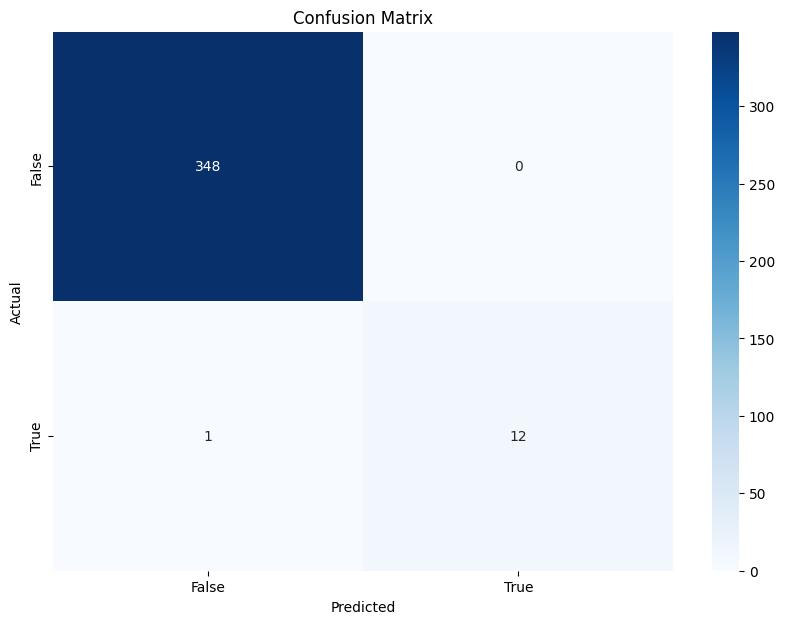

In [32]:
# plot confusion matrix to see conflated cancer types
plt.figure(figsize=(10, 7))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

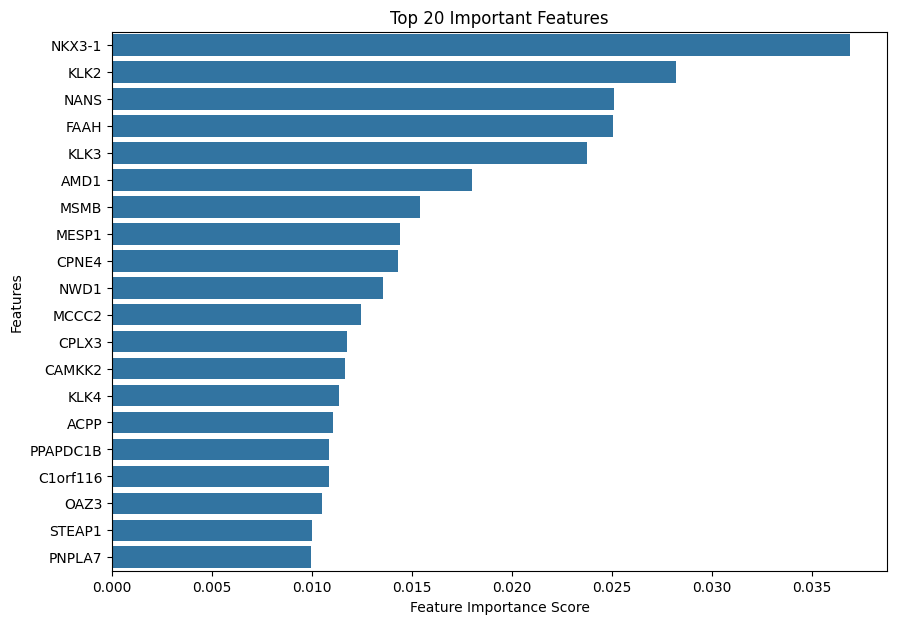

In [33]:
# find top 20 important features
top_20_features = feature_importances.head(20)
# plot top 20 important features
plt.figure(figsize=(10, 7))
sns.barplot(x=top_20_features.values, y=top_20_features.index)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Important Features")
plt.show()

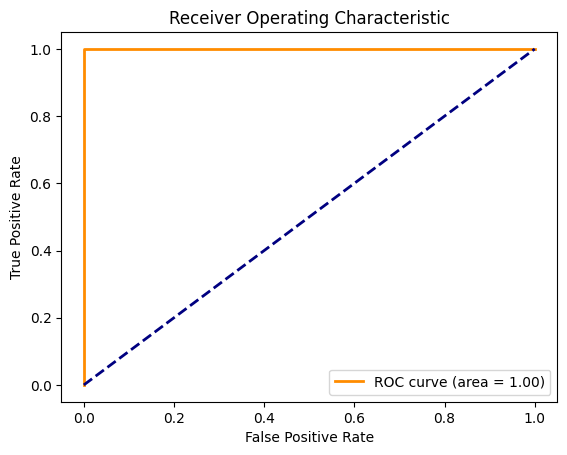

In [37]:
# add roc curve
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy',
            lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()